<a href="https://colab.research.google.com/github/maadishettyh13-dot/minor-project-spotify-/blob/main/Major_Project_Cardio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Pre-processing Complete. Missing values:
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


/tmp/ipykernel_1558/483758649.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cardio', data=df, palette='viridis')


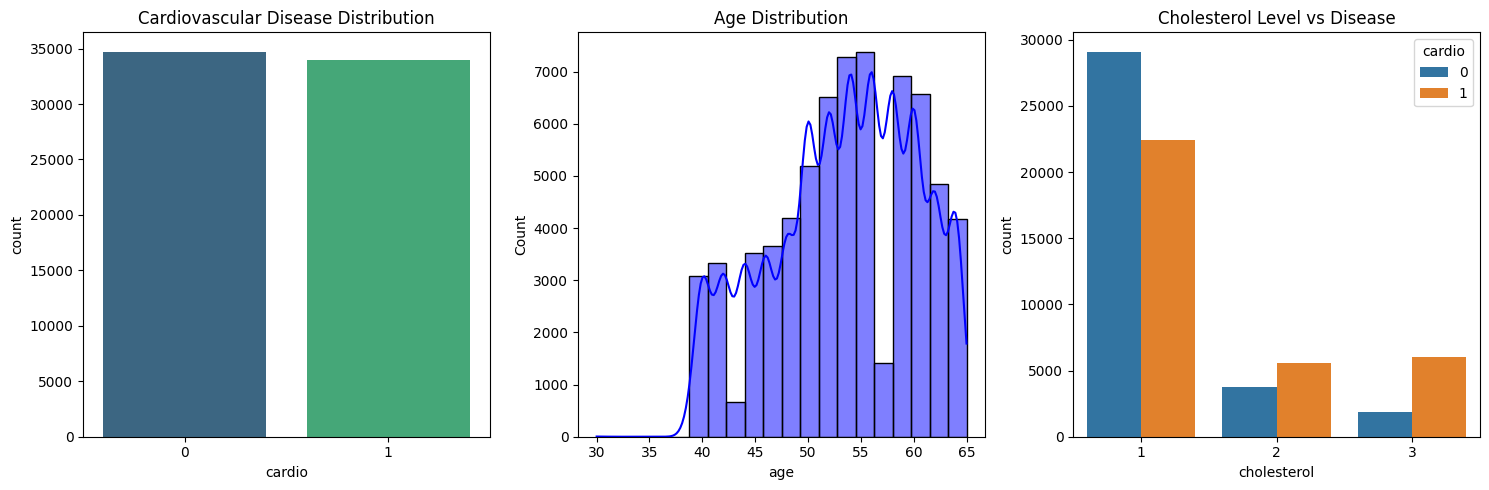

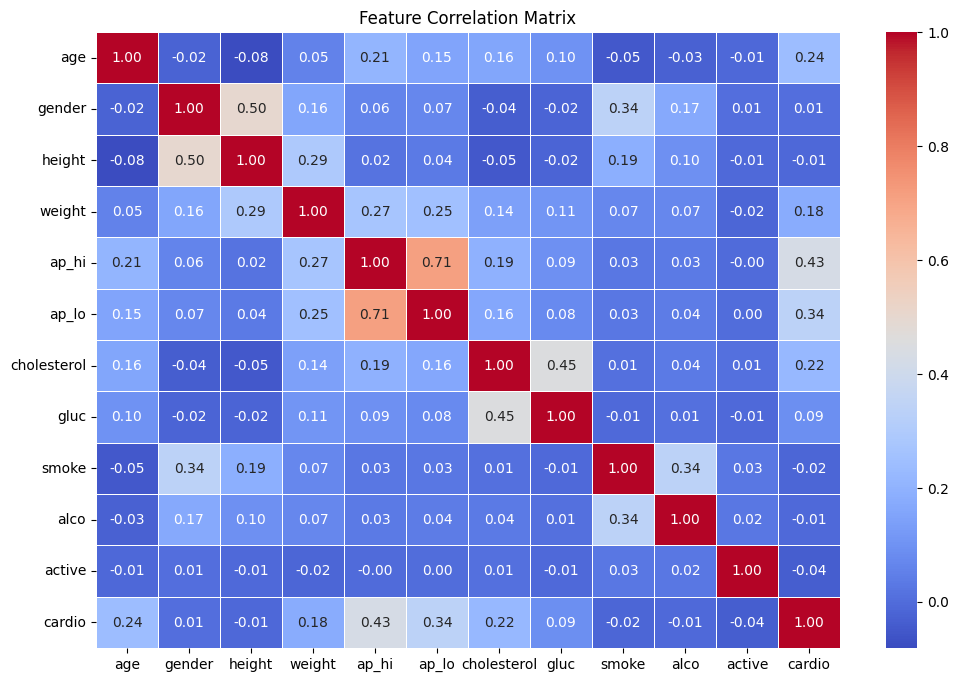


--- Model Performance Comparison ---
Logistic Regression Accuracy: 0.7237
SVM Accuracy: 0.7323
KNN Accuracy: 0.6930
Decision Tree Accuracy: 0.6319
Random Forest Accuracy: 0.6981


/tmp/ipykernel_1558/483758649.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette='magma')


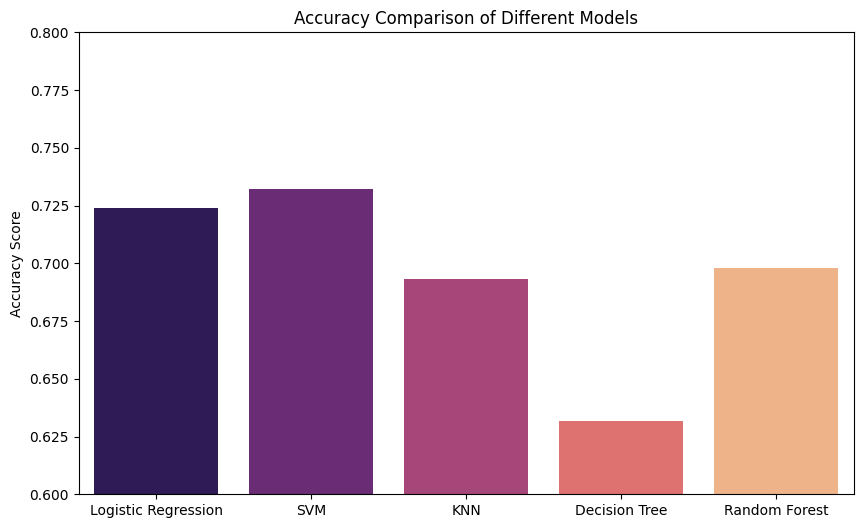


Final Selected Model: SVM

Detailed Classification Report for Final Model:
              precision    recall  f1-score   support

           0       0.71      0.79      0.75      6931
           1       0.76      0.67      0.71      6816

    accuracy                           0.73     13747
   macro avg       0.74      0.73      0.73     13747
weighted avg       0.73      0.73      0.73     13747



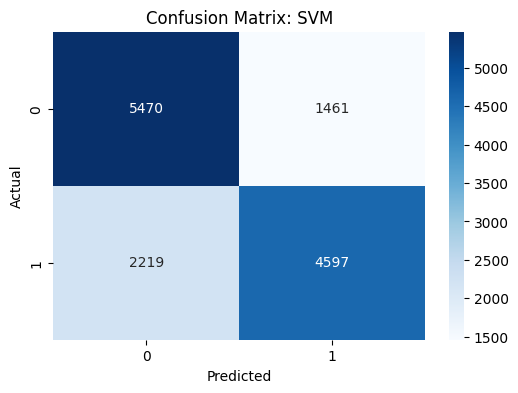

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==========================================
# 2. DATA PRE-PROCESSING
# ==========================================
# Load the dataset
file_path = '/content/upload_ff1150f6-d990-4955-8886-34059bc9cb36.csv'
df = pd.read_csv(file_path, sep=';') # Added sep=';' to correctly parse the CSV

# Convert age from days to years
df['age'] = (df['age'] / 365).round().astype(int)

# Removing outliers in blood pressure (ap_hi and ap_lo)
# Systolic (ap_hi) and Diastolic (ap_lo) should be within physiological limits
df = df[(df['ap_hi'] < 250) & (df['ap_hi'] > 60)]
df = df[(df['ap_lo'] < 150) & (df['ap_lo'] > 40)]

# Drop the 'id' column as it is not a predictive feature
df.drop('id', axis=1, inplace=True)

print("Data Pre-processing Complete. Missing values:")
print(df.isnull().sum())

# ==========================================
# 3. DATA ANALYSIS AND VISUALIZATION
# ==========================================
plt.figure(figsize=(15, 5))

# Plot 1: Target distribution
plt.subplot(1, 3, 1)
sns.countplot(x='cardio', data=df, hue='cardio', palette='viridis', legend=False) # Add hue and legend=False to address FutureWarning
plt.title('Cardiovascular Disease Distribution')

# Plot 2: Age distribution
plt.subplot(1, 3, 2)
sns.histplot(df['age'], bins=20, kde=True, color='blue')
plt.title('Age Distribution')

# Plot 3: Cholesterol levels vs Cardio
plt.subplot(1, 3, 3)
sns.countplot(x='cholesterol', hue='cardio', data=df)
plt.title('Cholesterol Level vs Disease')

plt.tight_layout()
plt.show()

# ==========================================
# 4. CORRELATION MATRIX
# ==========================================
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

# ==========================================
# 5. TRAIN TEST SPLIT & CLASSIFICATION
# ==========================================
X = df.drop('cardio', axis=1)
y = df['cardio']

# Split the data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (Crucial for SVM, KNN, and Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the models to compare
models = {
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(kernel='rbf'),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# ==========================================
# 6. COMPARE ACCURACY
# ==========================================
accuracies = {}

print("\n--- Model Performance Comparison ---")
for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)
    # Predict
    y_pred = model.predict(X_test_scaled)
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    accuracies[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

# Visualize Accuracy Comparison
plt.figure(figsize=(10, 6))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette='magma')
plt.title('Accuracy Comparison of Different Models')
plt.ylabel('Accuracy Score')
plt.ylim(0.6, 0.8)
plt.show()

# ==========================================
# 7. FINAL MODEL
# ==========================================
best_model_name = max(accuracies, key=accuracies.get)
print(f"\nFinal Selected Model: {best_model_name}")

# Training the best model again to display detailed report
final_model = models[best_model_name]
final_model.fit(X_train_scaled, y_train)
final_pred = final_model.predict(X_test_scaled)

print("\nDetailed Classification Report for Final Model:")
print(classification_report(y_test, final_pred))

# Confusion Matrix for the final model
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, final_pred), annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix: {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()